In [19]:
import importlib
import src.ingestion
import src.preproc
import src.eda
import src.garch
importlib.reload(src.ingestion)
importlib.reload(src.preproc)
importlib.reload(src.eda)
importlib.reload(src.garch)
from src.ingestion import *
from src.preproc import *
from src.eda import *
from src.garch import *
unified = pd.read_csv(filepath_or_buffer=r"insights\unified.csv")

### Data Loading and Preprocessing

In [19]:
download_assets()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

=== Asset Price Data Collection ===
Saved → dataset\BTC-USD.csv
Saved → dataset\ETH-USD.csv



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Saved → dataset\^GSPC.csv
Saved → dataset\^GSPTSE.csv
Saved → dataset\^HSI.csv
Saved → dataset\^BVSP.csv



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Saved → dataset\^AXJO.csv
Saved → dataset\^NSEI.csv
Saved → dataset\GC=F.csv
Saved → dataset\USDINR=X.csv
Saved → dataset\CAD=X.csv



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Saved → dataset\HKD=X.csv
Saved → dataset\BRL=X.csv
Saved → dataset\AUD=X.csv
=== Data Collection Complete ===


In [20]:
nan_summary = check_nan_across_files()
nan_summary.head()

=== NaN CHECK ACROSS ALL FILES ===

File: AUD=X.csv
Shape: (1561, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: BRL=X.csv
Shape: (1561, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: BTC-USD.csv
Shape: (2191, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: CAD=X.csv
Shape: (1561, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: ETH-USD.csv
Shape: (2191, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: GC=F.csv
Shape: (1509, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: HKD=X.csv
Shape: (1561, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: USDINR=X.csv
Shape: (1561, 7)
Total NaNs: 0 (0.0000%)
No NaNs found.
-------------------------

,file,rows,cols,total_nans,nan_pct
0,AUD=X.csv,1561,7,0,0.0
1,BRL=X.csv,1561,7,0,0.0
2,BTC-USD.csv,2191,7,0,0.0
3,CAD=X.csv,1561,7,0,0.0
4,ETH-USD.csv,2191,7,0,0.0


In [21]:
calendar_summary = check_calendar_alignment()
calendar_summary.head()

=== CALENDAR ALIGNMENT CHECK ===

Global date range: 2020-01-01 → 2025-12-30
Total unique dates (union): 2191

Common dates across ALL assets: 1299
Overlap ratio: 0.5929

AUD=X:
  available: 1561
  missing: 630 (28.75%)
  sample missing: [datetime.date(2020, 1, 4), datetime.date(2020, 1, 5), datetime.date(2020, 1, 11), datetime.date(2020, 1, 12), datetime.date(2020, 1, 18)]
----------------------------------------
BRL=X:
  available: 1561
  missing: 630 (28.75%)
  sample missing: [datetime.date(2020, 1, 4), datetime.date(2020, 1, 5), datetime.date(2020, 1, 11), datetime.date(2020, 1, 12), datetime.date(2020, 1, 18)]
----------------------------------------
BTC-USD:
  available: 2191
  missing: 0 (0.00%)
----------------------------------------
CAD=X:
  available: 1561
  missing: 630 (28.75%)
  sample missing: [datetime.date(2020, 1, 4), datetime.date(2020, 1, 5), datetime.date(2020, 1, 11), datetime.date(2020, 1, 12), datetime.date(2020, 1, 18)]
----------------------------------------

,ticker,available_dates,missing_dates,missing_pct
12,^HSI,1475,716,32.679142
13,^NSEI,1485,706,32.222729
9,^BVSP,1494,697,31.811958
11,^GSPTSE,1505,686,31.309904
10,^GSPC,1507,684,31.218622


In [22]:
keep_common_dates()

=== KEEPING ONLY COMMON DATES ACROSS ALL ASSETS ===

Common dates retained: 1299
AUD=X: 1561 → 1299 rows
BRL=X: 1561 → 1299 rows
BTC-USD: 2191 → 1299 rows
CAD=X: 1561 → 1299 rows
ETH-USD: 2191 → 1299 rows
GC=F: 1509 → 1299 rows
HKD=X: 1561 → 1299 rows
USDINR=X: 1561 → 1299 rows
^AXJO: 1518 → 1299 rows
^BVSP: 1494 → 1299 rows
^GSPC: 1507 → 1299 rows
^GSPTSE: 1505 → 1299 rows
^HSI: 1475 → 1299 rows
^NSEI: 1485 → 1299 rows

=== ALL FILES NOW PERFECTLY ALIGNED ===


In [23]:
convert_all_to_inr()

=== CONVERTING ALL ASSETS TO INR ===

Processing BTC-USD...
✔ Converted BTC-USD to INR
Processing ETH-USD...
✔ Converted ETH-USD to INR
Processing GC=F...
✔ Converted GC=F to INR
Processing ^AXJO...
✔ Converted ^AXJO to INR
Processing ^BVSP...
✔ Converted ^BVSP to INR
Processing ^GSPC...
✔ Converted ^GSPC to INR
Processing ^GSPTSE...
✔ Converted ^GSPTSE to INR
Processing ^HSI...
✔ Converted ^HSI to INR
Processing ^NSEI...
✔ Converted ^NSEI to INR

=== ALL FILES CONVERTED TO INR ===


### EDA

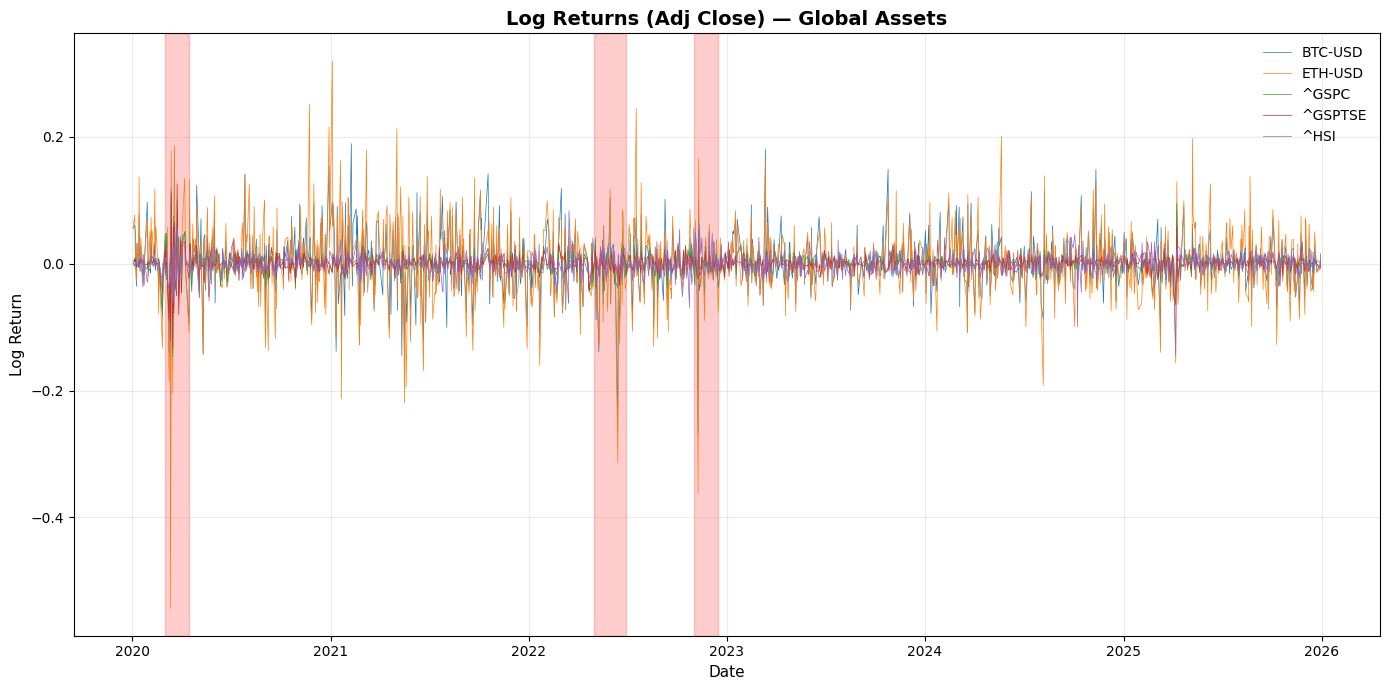

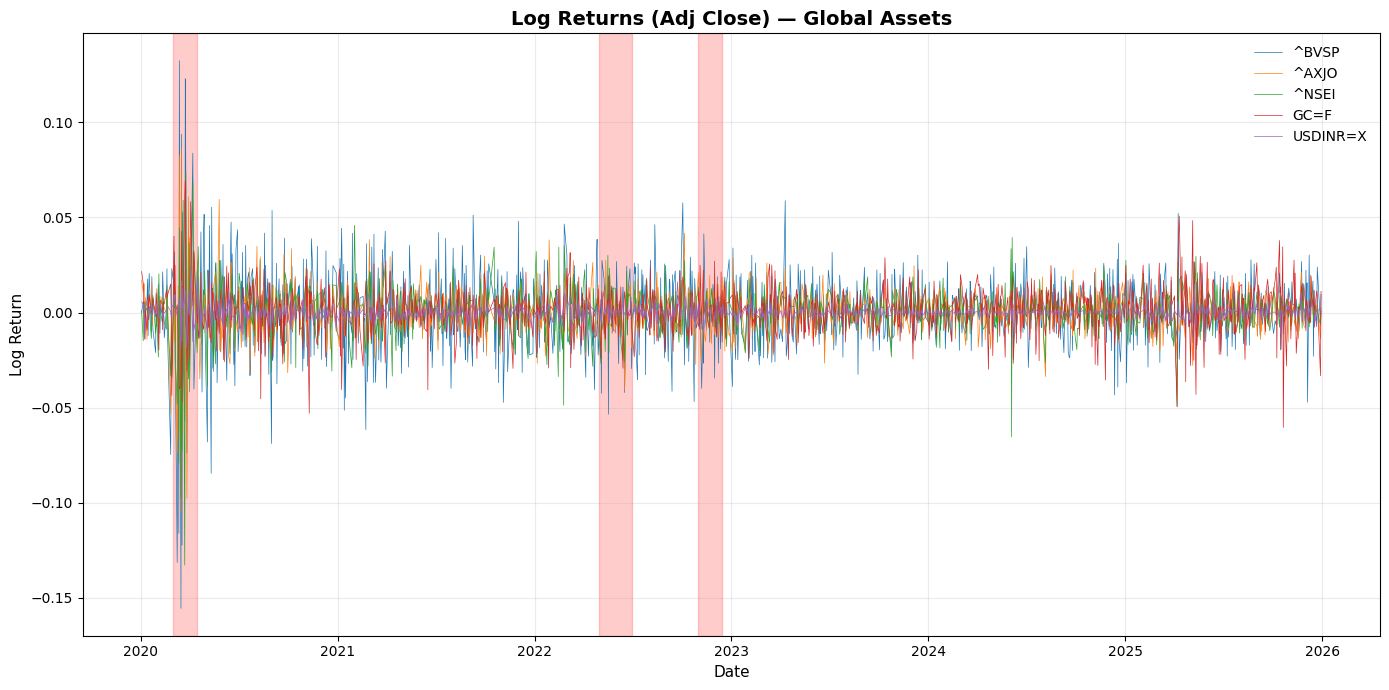

In [49]:
plot_global_log_returns(batch_size=5)

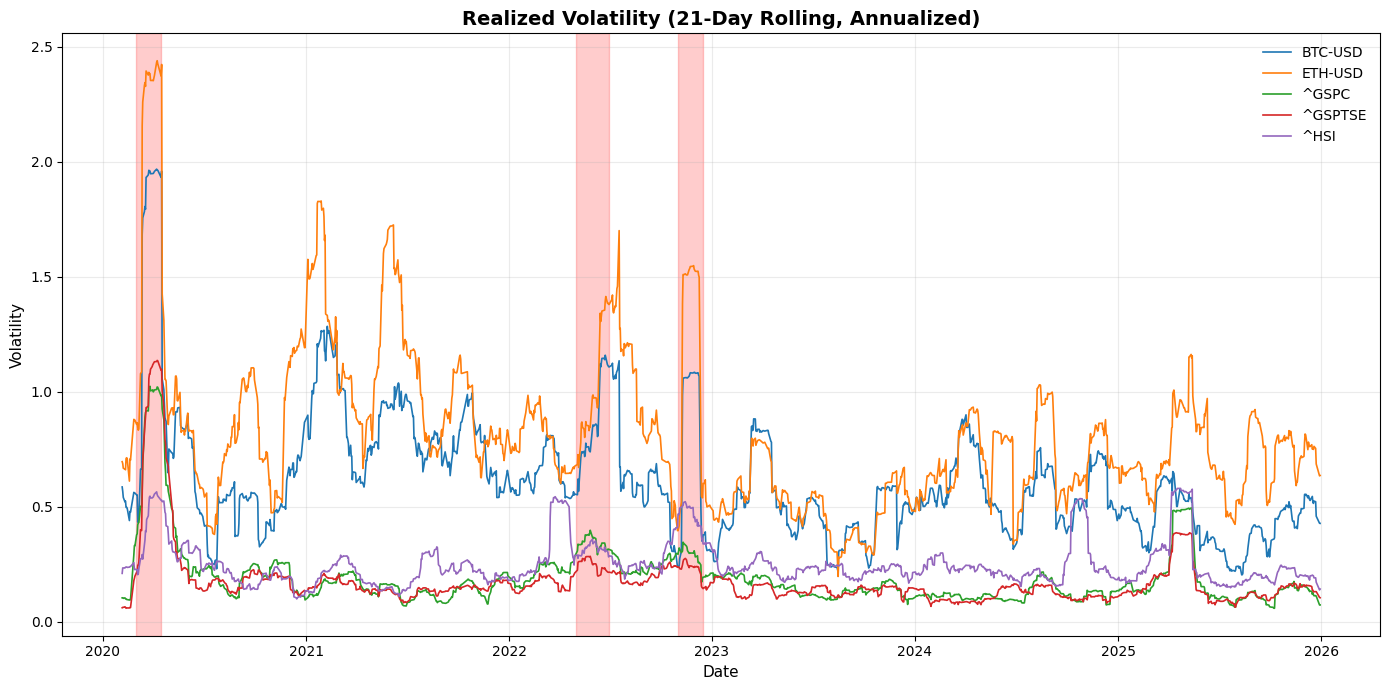

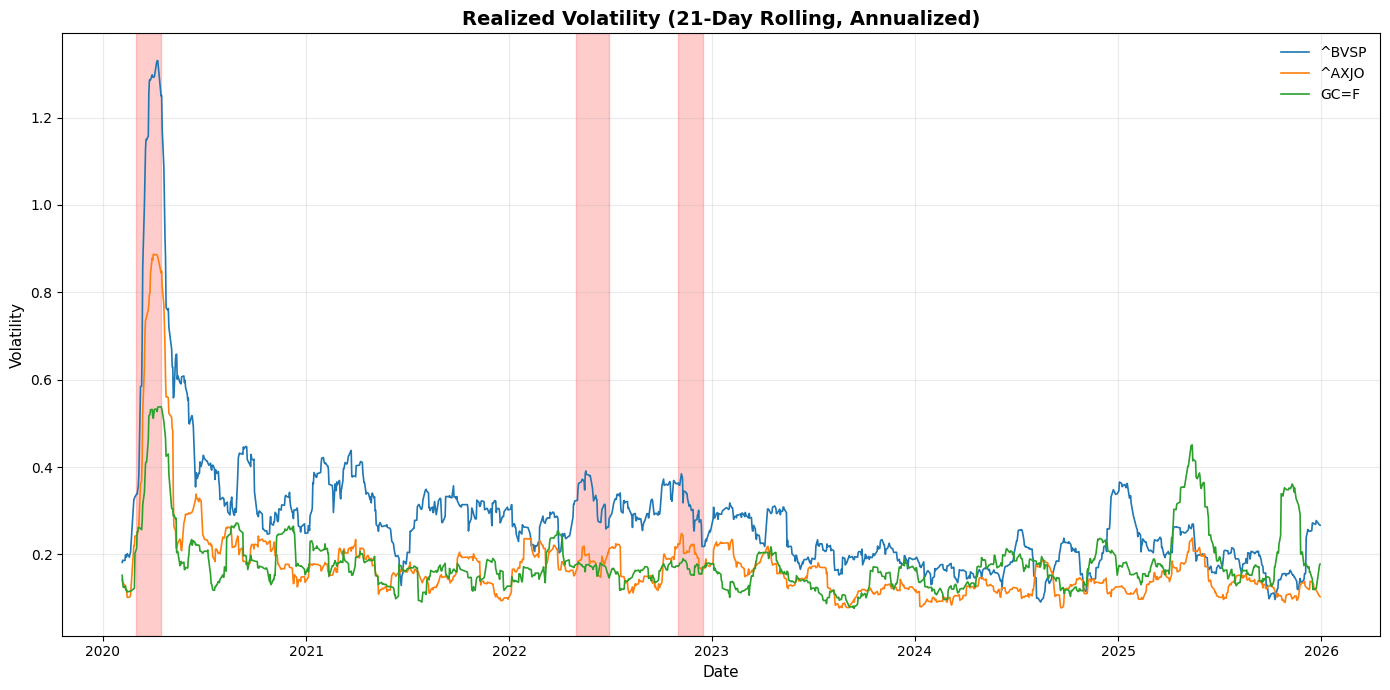

In [50]:
plot_realized_volatility(batch_size=5)

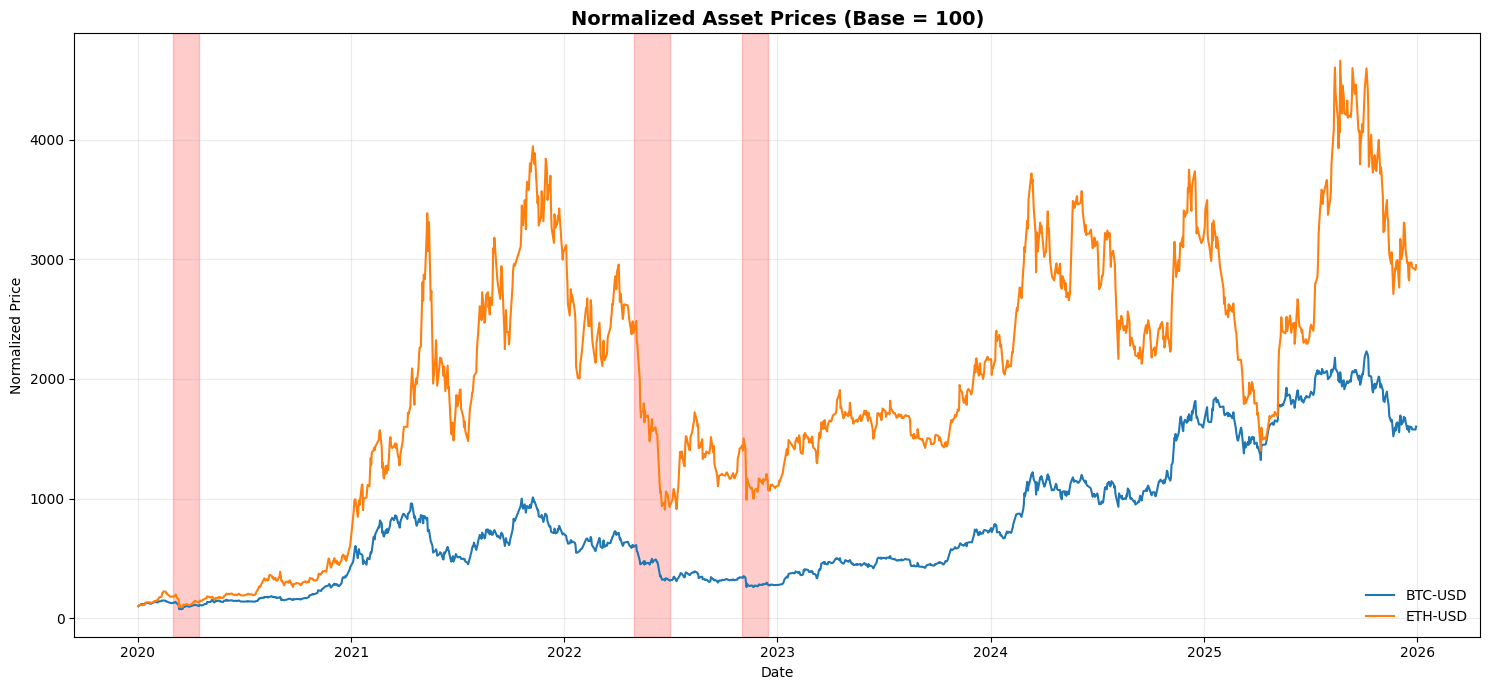

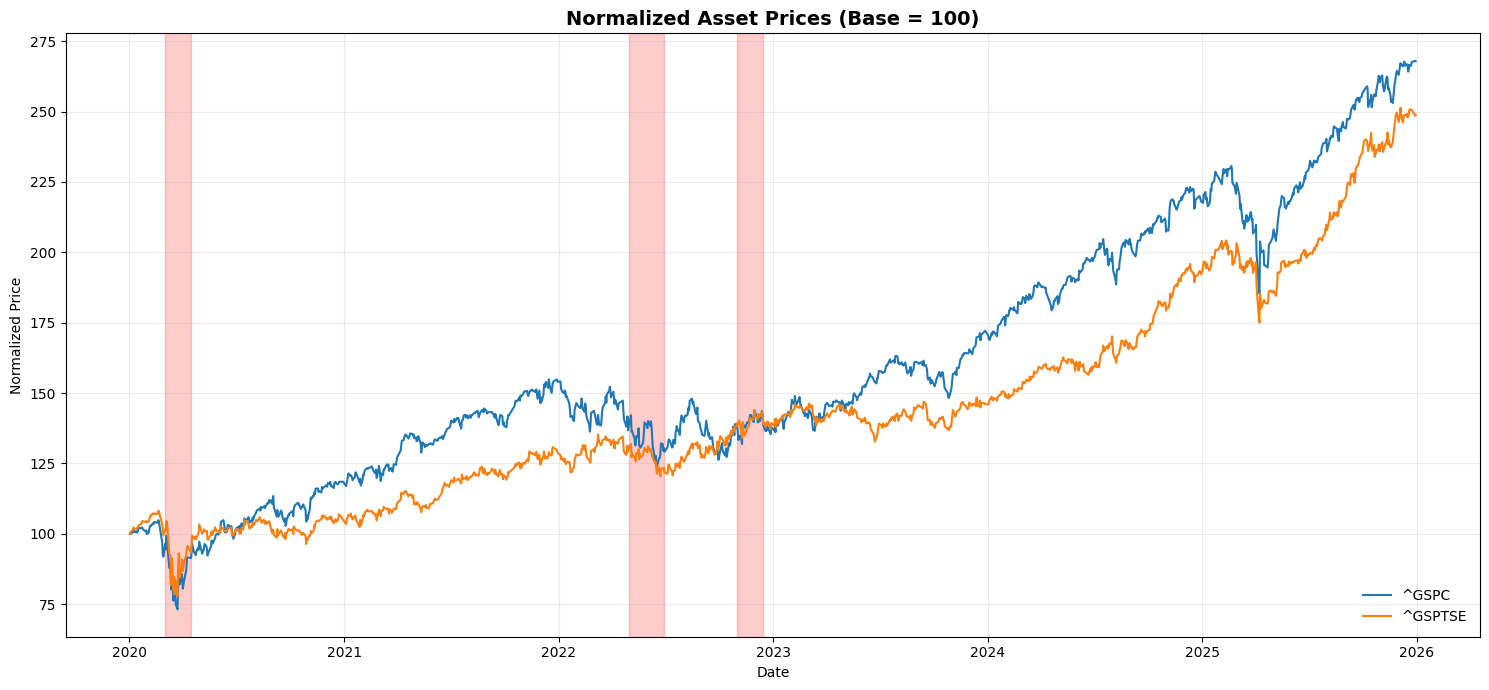

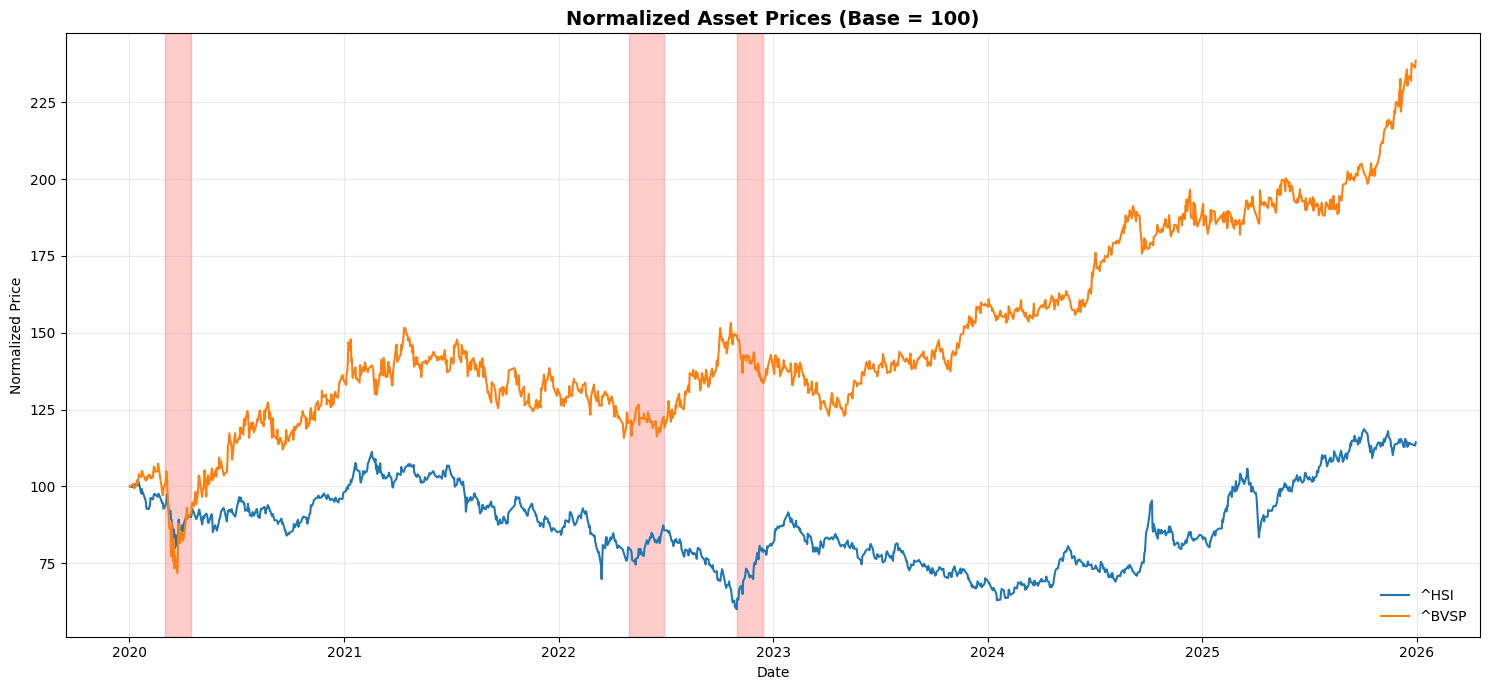

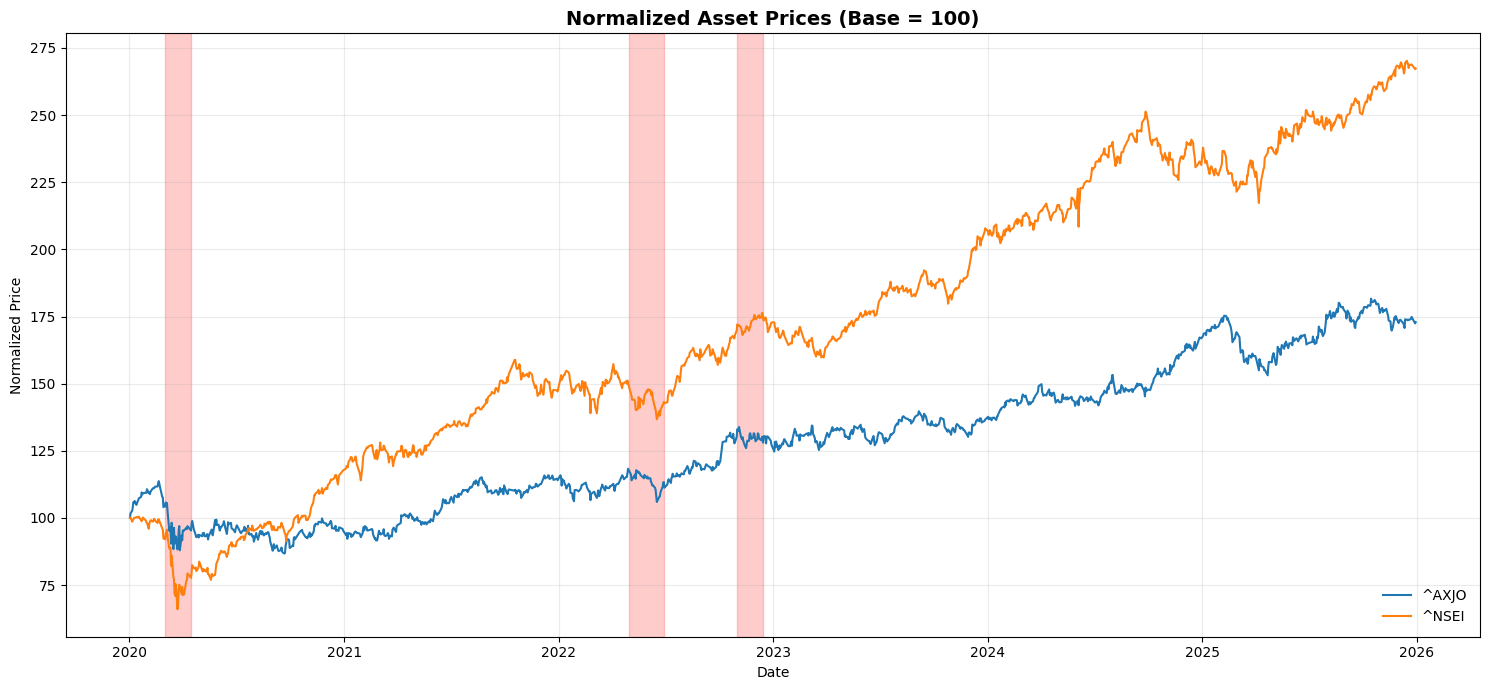

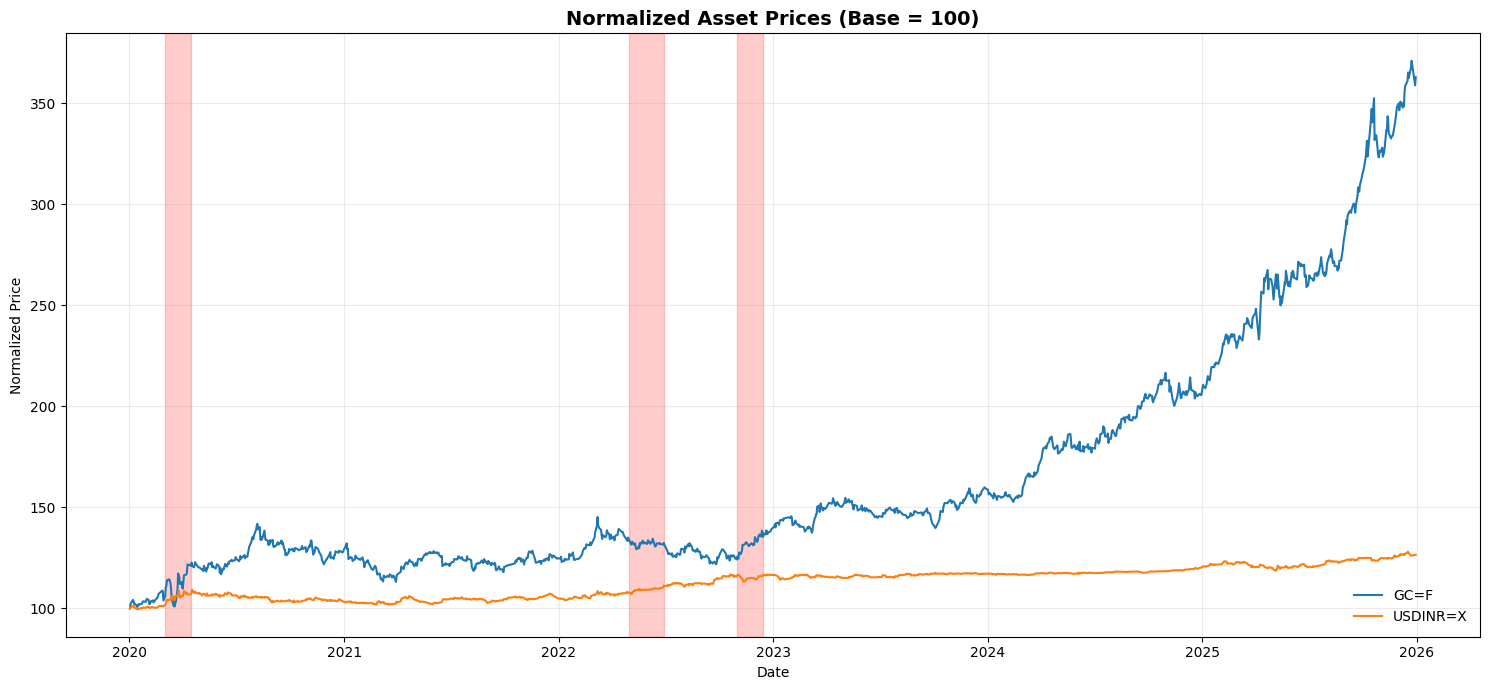

In [51]:
plot_normalized_prices(batch_size=2)

In [3]:
unified = build_unified_matrix()

Saved unified matrix → insights\unified.csv

=== UNIFIED MATRIX INFO ===
(1278, 21)
        date  ret_BTC-USD  vol_BTC-USD  ret_ETH-USD  vol_ETH-USD  ret_^GSPC  \
0 2020-02-05     0.043022     0.586900     0.073169     0.696824   0.008181   
1 2020-02-06     0.013158     0.568214     0.040061     0.688566   0.004445   
2 2020-02-07     0.010841     0.541487     0.051824     0.668084  -0.001350   
3 2020-02-10     0.006811     0.522185     0.004207     0.664651   0.007936   
4 2020-02-11     0.031754     0.525412     0.050390     0.661616  -0.001611   

   vol_^GSPC  ret_^GSPTSE  vol_^GSPTSE  ret_^HSI  ...  ret_^BVSP  vol_^BVSP  \
0   0.104812     0.004020     0.061598  0.001188  ...   0.002684   0.181578   
1   0.104895     0.007249     0.063404  0.026788  ...  -0.010860   0.186715   
2   0.102560    -0.001717     0.063367  0.000817  ...   0.002749   0.186117   
3   0.104633     0.007370     0.065659 -0.005027  ...  -0.000759   0.186173   
4   0.100282    -0.000687     0.063363  0.0092

### DCC GARCH

In [11]:
resid, vol, summary = run_univariate_garch()

=== RUNNING UNIVARIATE GARCH ===

Processing BTC-USD...
Processing ETH-USD...
Processing ^GSPC...
Processing ^GSPTSE...
Processing ^HSI...
Processing ^BVSP...
Processing ^AXJO...
Processing ^NSEI...
Processing GC=F...
Processing USDINR=X...

=== GARCH SUMMARY ===
      asset      arch_pval     omega         nu     alpha      beta  \
0   BTC-USD   2.342661e-07  0.450599   3.097180  0.079473  0.914118   
1   ETH-USD   1.178055e-11  0.856265   3.463771  0.064422  0.915885   
2     ^GSPC   3.032256e-78  0.049673   5.981391  0.159305  0.816846   
3   ^GSPTSE  3.613744e-101  0.096966   9.684830  0.160873  0.755397   
4      ^HSI   1.313762e-06  0.171831   7.461534  0.083026  0.851114   
5     ^BVSP   2.448394e-99  0.035153  11.484736  0.051425  0.935019   
6     ^AXJO  7.299128e-105  0.021500   7.330713  0.036595  0.941410   
7     ^NSEI   8.439539e-81  0.034691   5.406695  0.090905  0.878092   
8      GC=F   2.628885e-28  0.071925   5.562609  0.063787  0.885536   
9  USDINR=X   9.029353e-64

In [7]:
dcc_corrs, dcc_summary = run_dcc_garch()

=== RUNNING DCC-GARCH ===
Observations: 1277
Assets: 10

=== DCC SUMMARY ===
               pair  full_sample_corr  covid_crash  luna_collapse  \
0  BTC-USD__ETH-USD          0.815108     0.891718       0.897083   
1    BTC-USD__^GSPC          0.347426     0.467849       0.528009   
2  BTC-USD__^GSPTSE          0.300876     0.518185       0.458554   
3     BTC-USD__^HSI          0.103813     0.280569       0.191262   
4    BTC-USD__^BVSP          0.200197     0.410761       0.289768   

   ftx_collapse  
0      0.918796  
1      0.419871  
2      0.445778  
3      0.132247  
4      0.195964  

Saved → insights\dcc_correlations.csv
Saved → insights\dcc_summary.csv


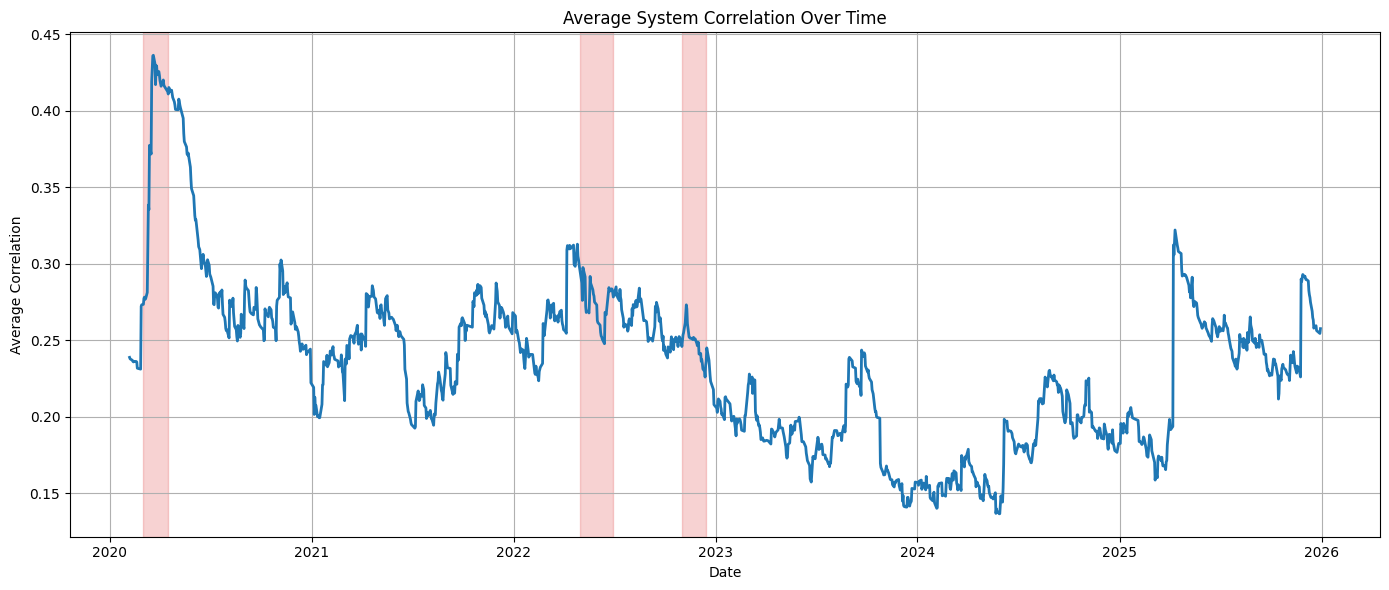

In [12]:
plot_avg_system_correlation()

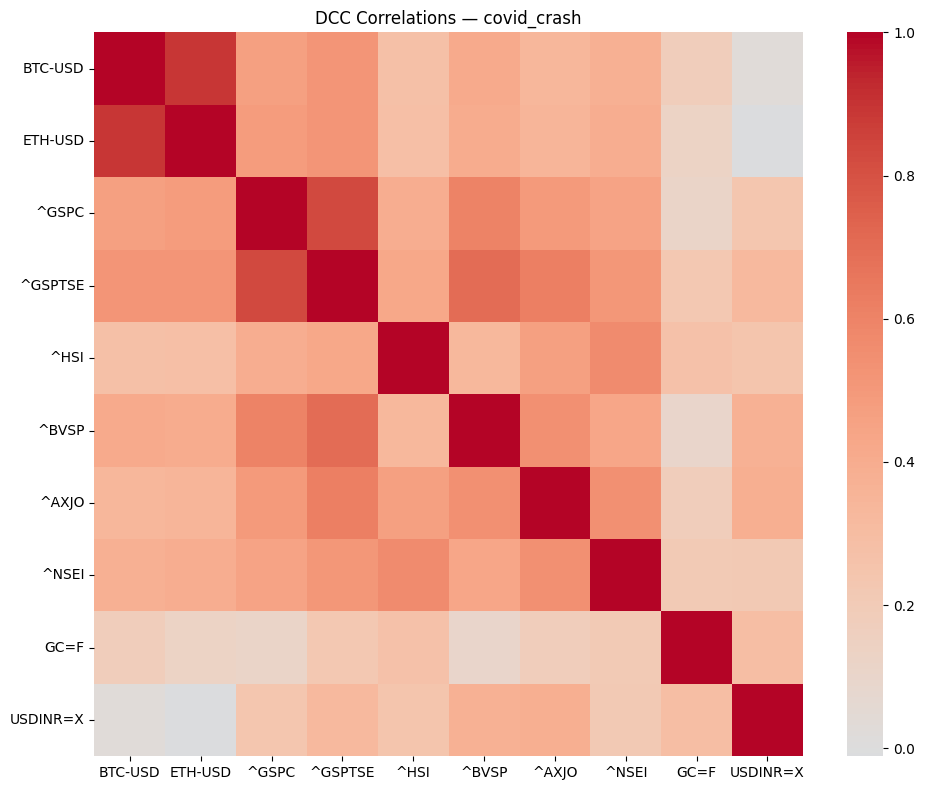

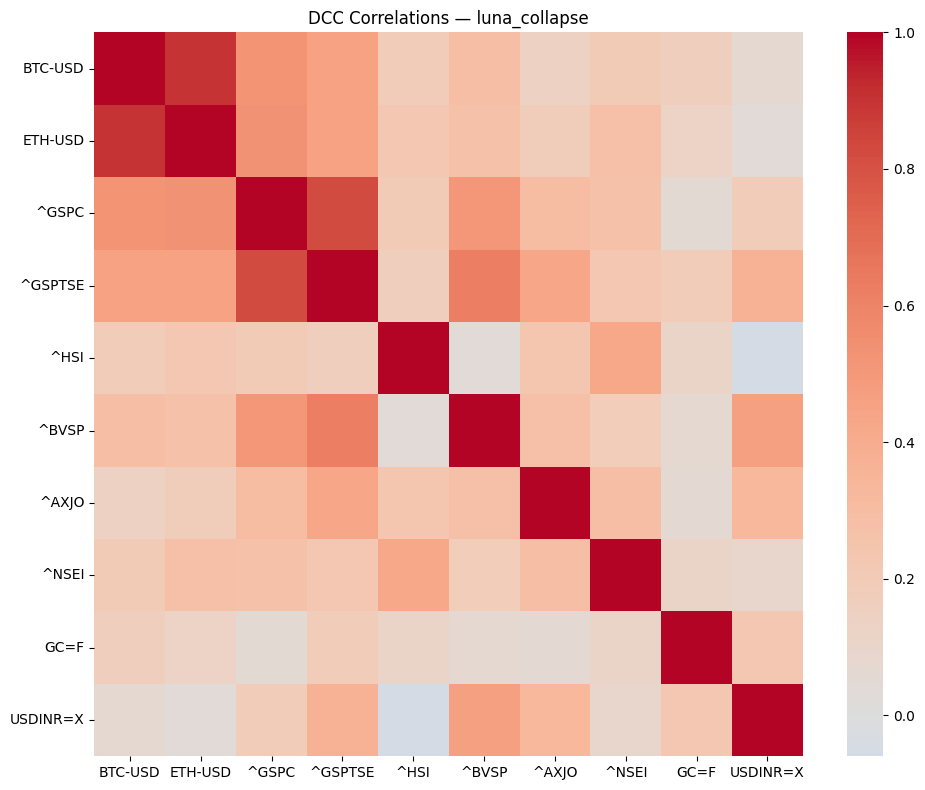

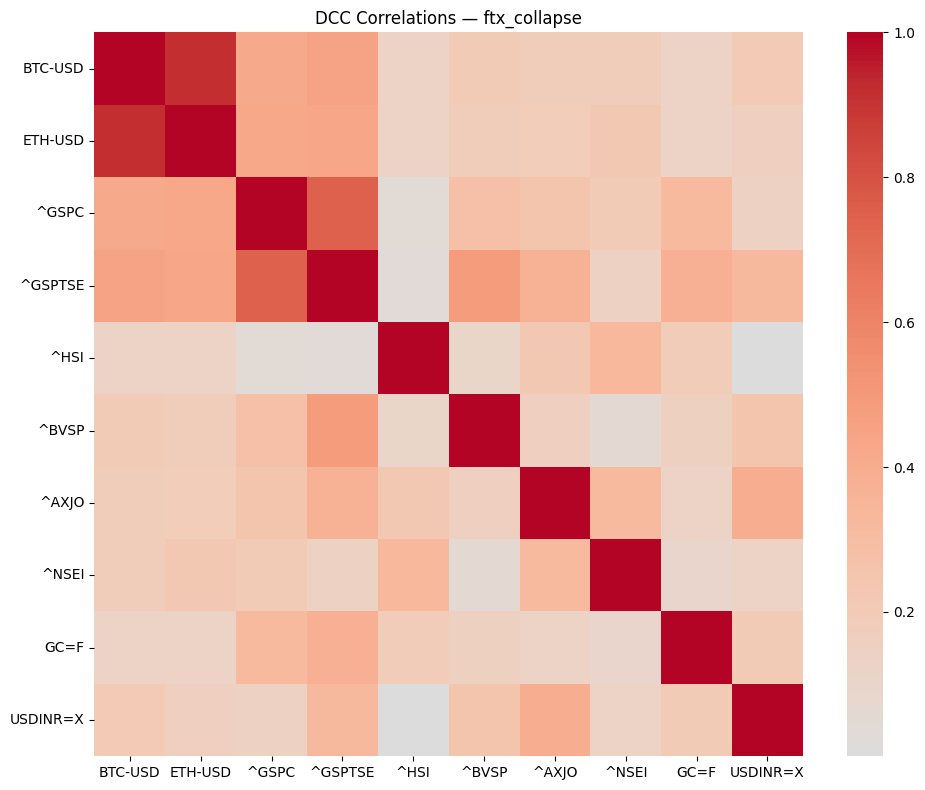

In [13]:
plot_regime_correlation_heatmaps()

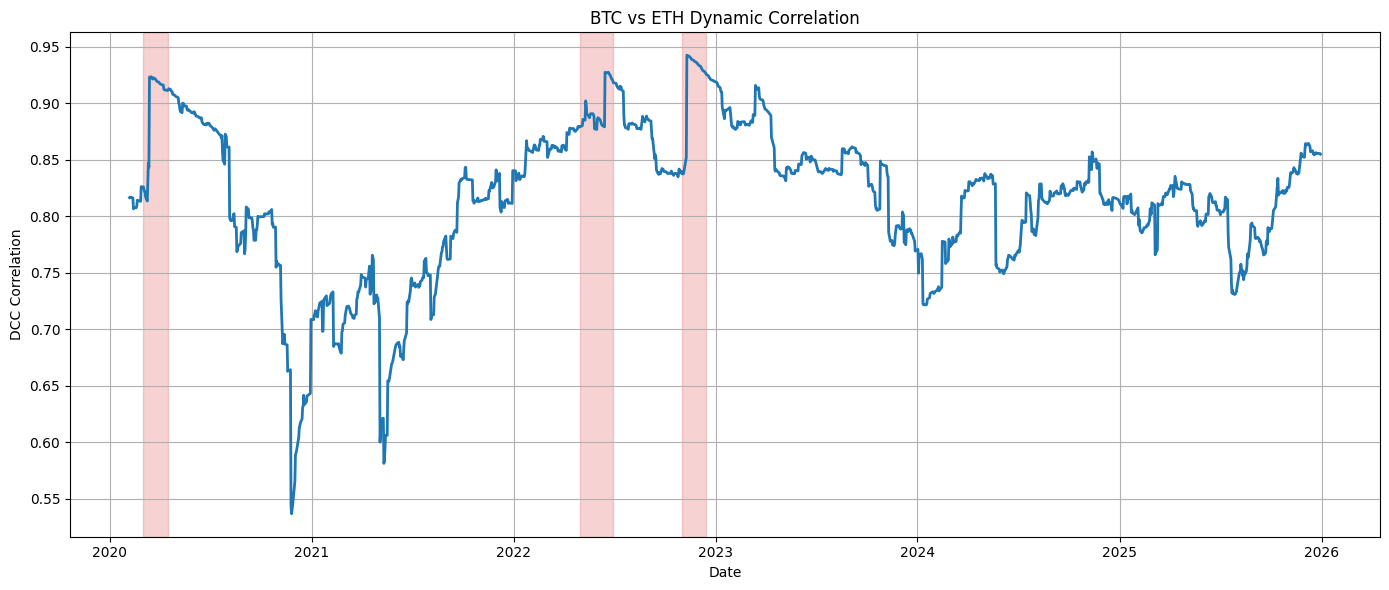

In [14]:
plot_btc_eth_dcc()

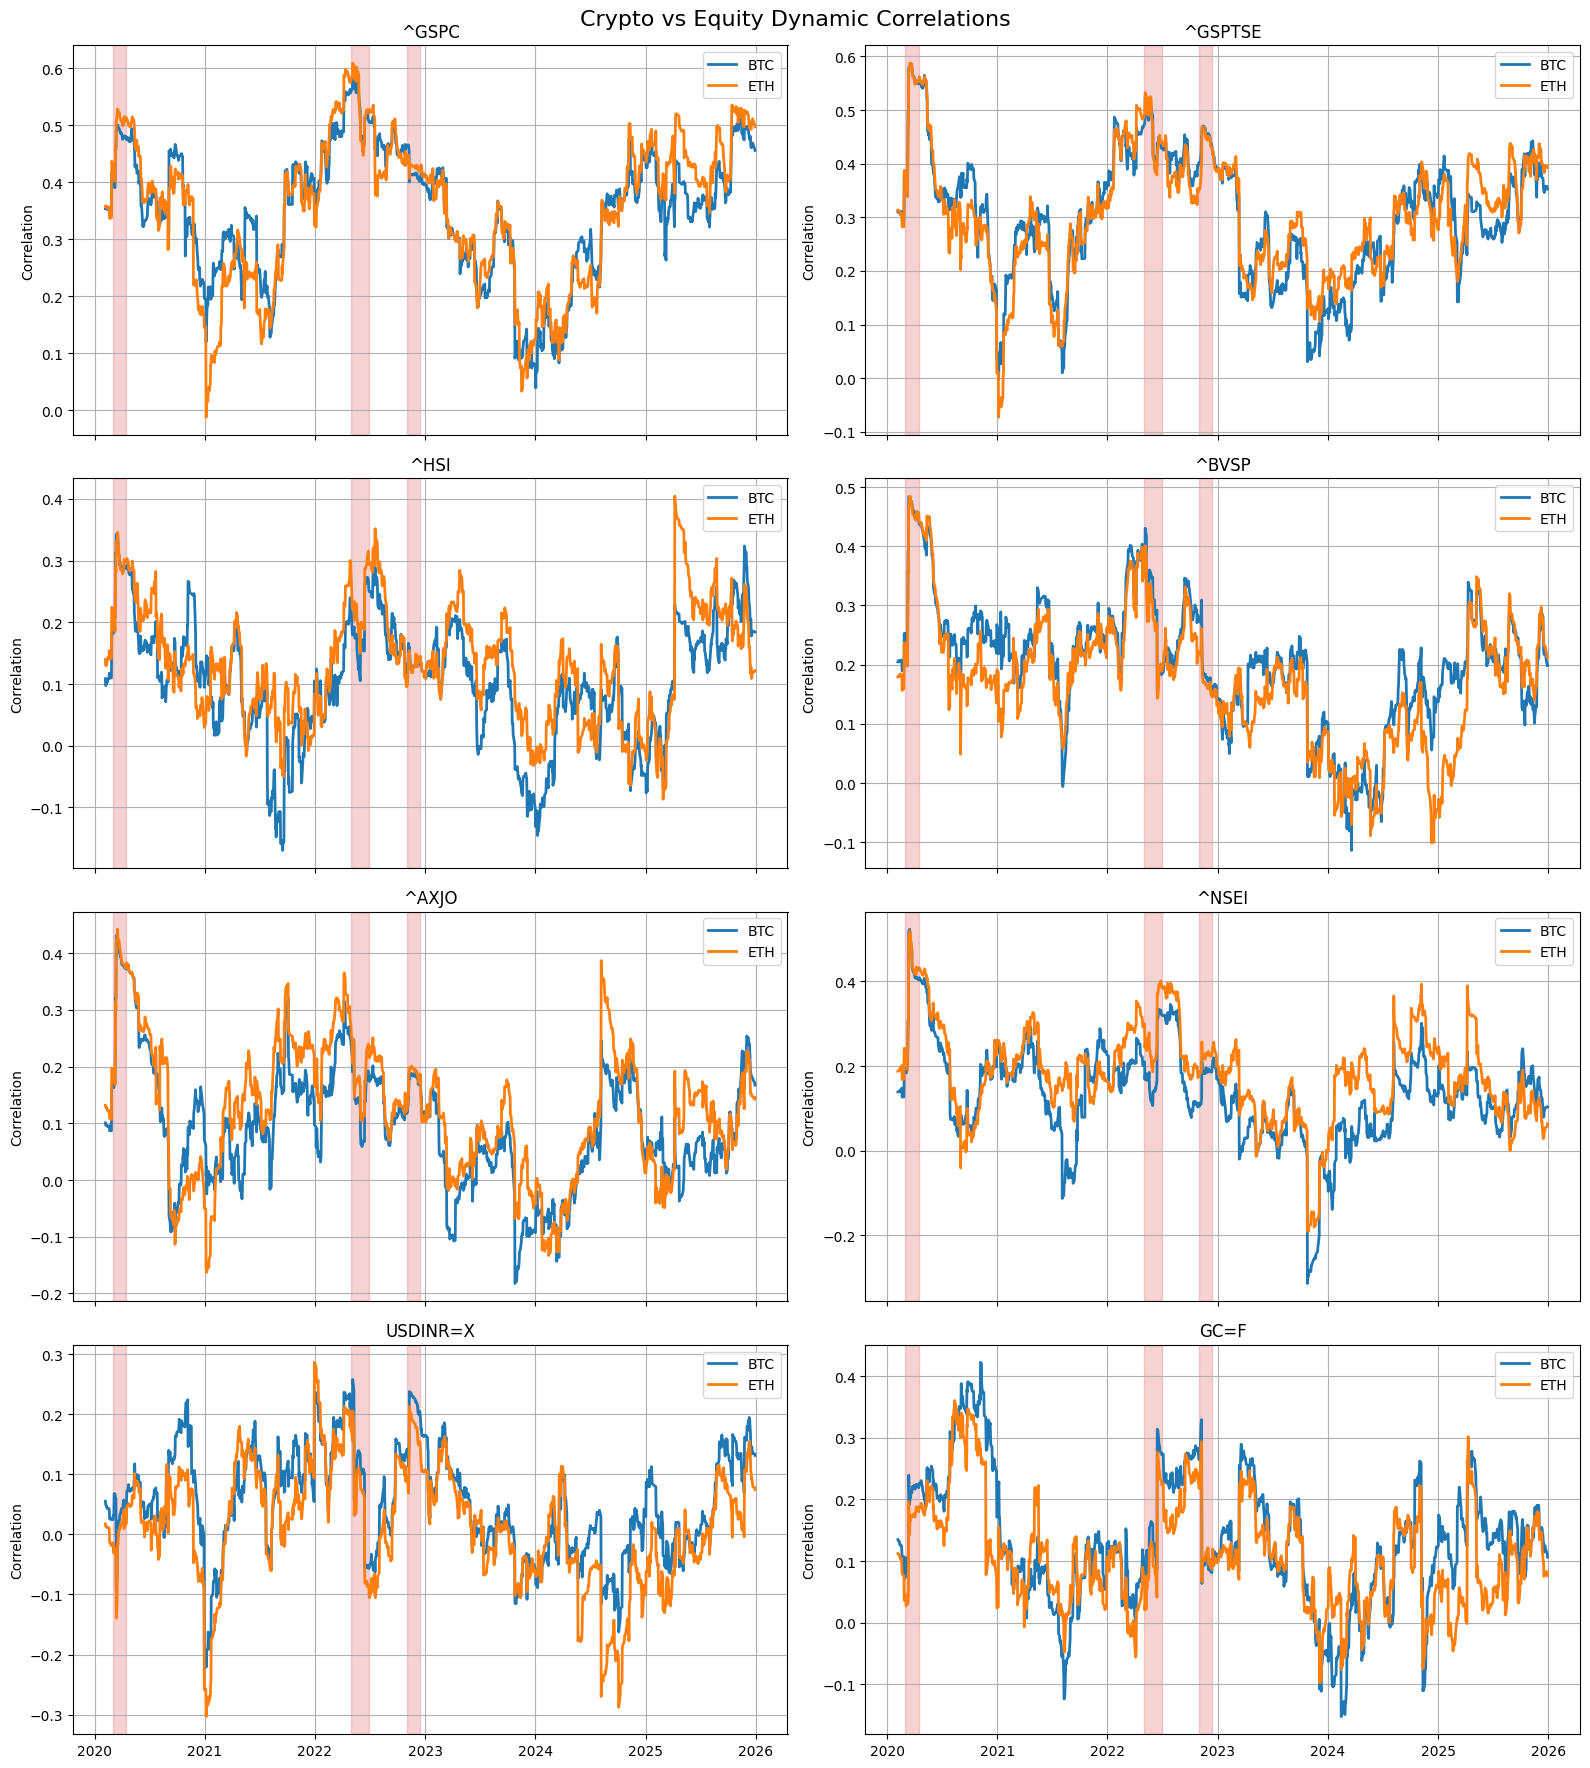

In [18]:
plot_crypto_equity_dcc()

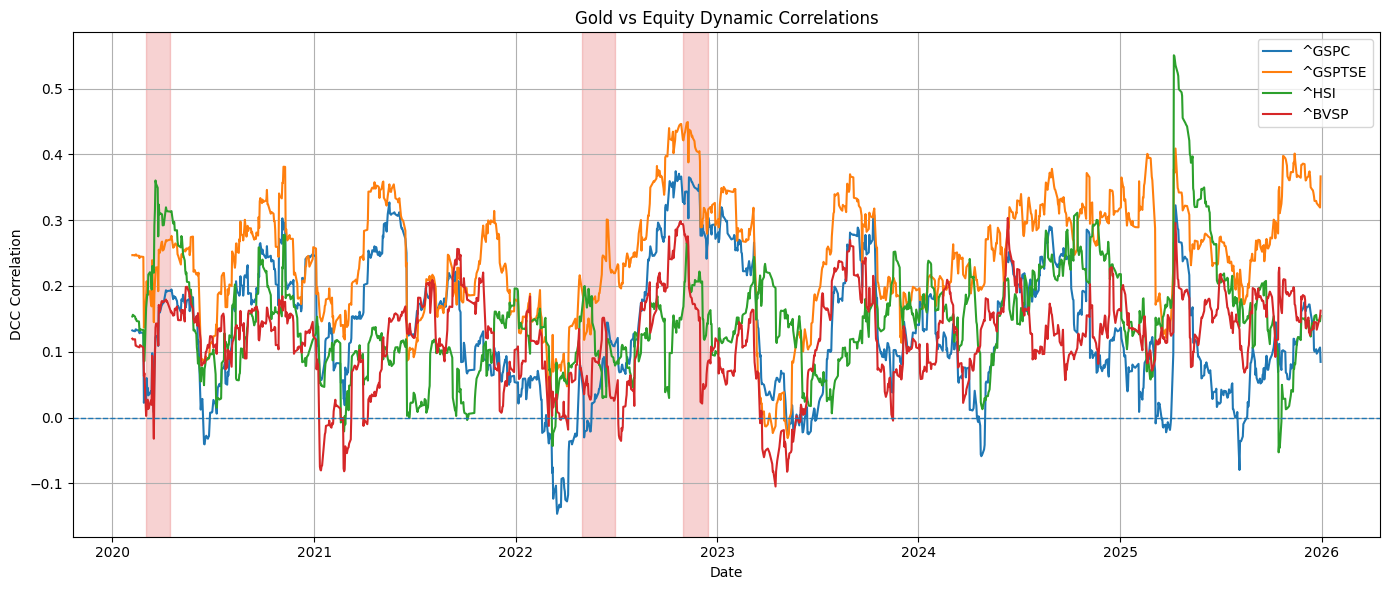

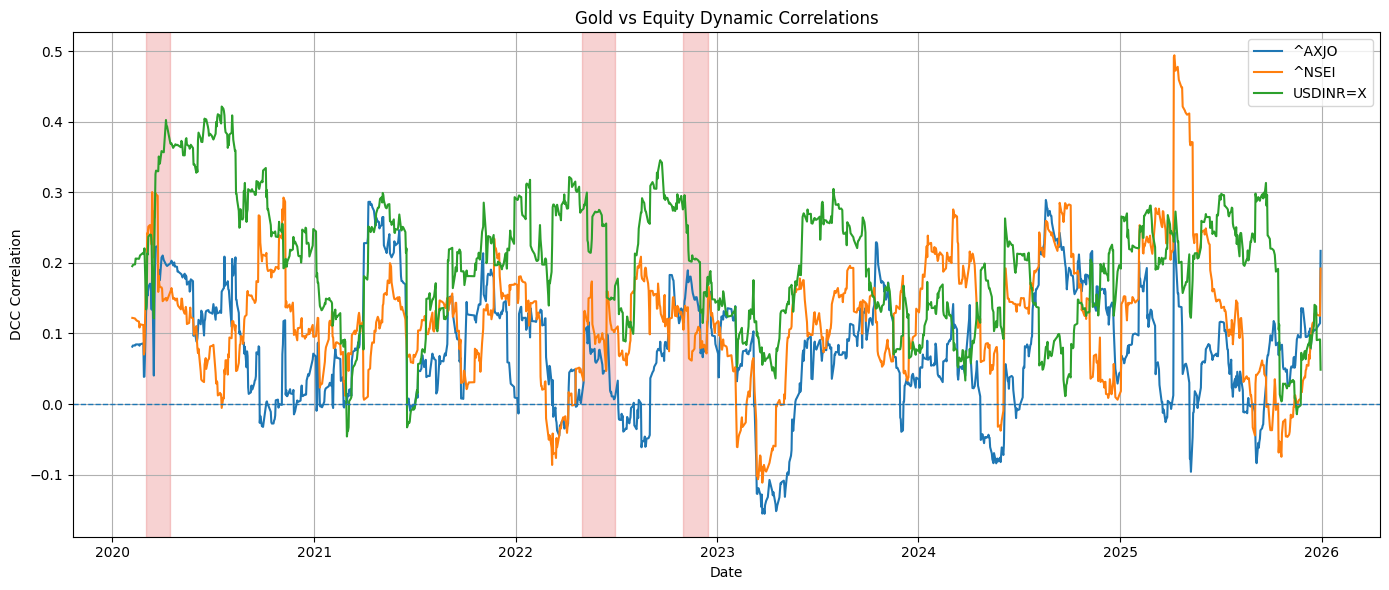

In [20]:
plot_gold_safe_haven(batch_size=4)